Test modifying original MAE to use geospatial encodings rather than postional encodings, no other changes

In [46]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

from functools import partial

import numpy as np
import pandas as pd
import xarray as xr

import torch
import torch.nn as nn

from timm.models.vision_transformer import PatchEmbed, Block

from matplotlib import pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision.utils import _log_api_usage_once
from lightning.pytorch import LightningModule, LightningDataModule, Trainer, seed_everything
from lightning.pytorch.callbacks import TQDMProgressBar
from lightning.pytorch.loggers import CSVLogger
from tqdm import tqdm

In [154]:
def get_lon_lat_sin_cos_embed(coords, embed_dim):
    omega = np.arange(embed_dim // 3 + 1, dtype=np.float32)
    omega /= embed_dim / 3.
    omega = 1. / (180/torch.pi)**omega  # (D/2,)
    # reverse omega to put 1st lat/lon harmonic first:
    omega = omega[::-1]
    omega = torch.tensor(omega.copy(), device=coords.device)
    
    out_lon = torch.einsum('bm,d->bmd', coords[:,0].reshape(coords.shape[0], -1), omega)
    emb_sin_lon = torch.sin(out_lon)
    emb_cos_lon = torch.cos(out_lon)
    
    out_lat = torch.einsum('bm,d->bmd', coords[:,1].reshape(coords.shape[0], -1), omega)
    emb_sin_lat = torch.sin(out_lat)
    
    emb = torch.stack([emb_sin_lon, emb_cos_lon, emb_sin_lat], -1)
    emb = emb.reshape(coords.shape[0], coords[0,0].numel(), -1)[...,:embed_dim]

    return emb


In [162]:
from torch.utils.data import Dataset, DataLoader
from lightning.pytorch import LightningDataModule
class GeoCloudsatDataset(Dataset):
    def __init__(self, files):
        super().__init__()
        self.files = files
    
    def __len__(self):
        return len(self.files)

    def load_image_and_geoloc(self, idx):
        with xr.open_datatree(self.files[idx]) as dt:
            image_input = dt.geo_patch.data.fillna(0)
            image_input = image_input[:3] / 100
            # image_input[:6] = image_input[:6] / 100
            # image_input[6:] = (image_input[6:] - 180) / 140 
            image_input = np.clip(image_input, 0, 1).values.astype(np.float32)# * 2 -1 # normalise in range [-1,1]

            time_of_day = (dt.geo_patch.t.values - dt.geo_patch.t.values.astype("datetime64[D]")) / np.timedelta64(1, "D").astype("timedelta64[ns]")
            time_of_year = (dt.geo_patch.t.values - dt.geo_patch.t.values.astype("datetime64[Y]")) / np.timedelta64(1, "Y").astype("timedelta64[ns]")

            # Fix latitude/longitude encoding:
            ds = dt.geo_patch
            if "latitude" in ds.data_vars and "longitude" in ds.data_vars:
                lat_offset = (
                    (ds.latitude.encoding["scale_factor"] + ds.latitude.encoding["add_offset"])*2
                    if ds.latitude.encoding["add_offset"] > 0
                    else 0
                )
                lon_offset = (
                    (ds.longitude.encoding["scale_factor"] + ds.longitude.encoding["add_offset"])*2
                    if ds.longitude.encoding["add_offset"] > 0
                    else 0
                )
                latitudes = (ds.latitude - lat_offset).fillna(ds.latitude.encoding["add_offset"])
                longitudes = (ds.longitude - lon_offset).fillna(ds.longitude.encoding["add_offset"])
            
            geoloc_input = np.stack([
                longitudes, 
                latitudes, 
                # dt.geo_patch.sat_angle[1], 
                # dt.geo_patch.sat_angle[0], 
                # dt.geo_patch.solar_angle[1], 
                # dt.geo_patch.solar_angle[0], 
                # np.full(dt.geo_patch.longitude.shape, time_of_day, np.float32), 
                # np.full(dt.geo_patch.longitude.shape, time_of_year, np.float32), 
            ], 0).astype(np.float32)

            # cloudsat_offset = (dt.cloudsat_unaligned.Nray.size-256)//2
            # cloudsat_unaligned = dt.cloudsat_unaligned.isel(Nray=slice(cloudsat_offset, cloudsat_offset+256))

            # target = (cloudsat_unaligned.IWC.fillna(0).values.astype(np.float32) - np.float32(0.005482884130160449) ) / np.float32(0.07499345171049679)
            
            
            # time_of_day = (cloudsat_unaligned.Profile_time.values - cloudsat_unaligned.Profile_time.values.astype("datetime64[D]")) / np.timedelta64(1, "D").astype("timedelta64[ns]")
            # time_of_year = (cloudsat_unaligned.Profile_time.values - cloudsat_unaligned.Profile_time.astype("datetime64[Y]")) / np.timedelta64(1, "Y").astype("timedelta64[ns]")
            
            # geoloc_output = np.stack([
            #     cloudsat_unaligned.Longitude, 
            #     cloudsat_unaligned.Latitude, 
            #     # np.full(cloudsat_unaligned.Longitude.shape, 0, np.float32), # 0 degree sat angle for all
            #     # np.full(cloudsat_unaligned.Longitude.shape, 0, np.float32), # 0 degree sat angle for all
            #     # cloudsat_azi, # need to calc solar angles
            #     # cloudsat_sza, # need to calc solar angles
            #     # np.full(cloudsat_unaligned.Longitude.shape, time_of_day, np.float32), 
            #     # np.full(cloudsat_unaligned.Longitude.shape, time_of_year, np.float32), 
            # ], 0).astype(np.float32)
            
        return image_input, geoloc_input#, target, geoloc_output
    
    def __getitem__(self, idx):
        return self.load_image_and_geoloc(idx)

class GeoCloudsatDataloader(LightningDataModule):
    def __init__(
        self, 
        batch_size, 
        files, 
        num_workers=0, 
    ):
        super().__init__()
        self.batch_size = batch_size
        self.num_workers = num_workers

        # Get list of files for each split
        self.train_dataset = GeoCloudsatDataset(files[:int(len(files)*0.7)])
        self.val_dataset = GeoCloudsatDataset(files[int(len(files)*0.75):int(len(files)*0.85)])
        self.test_dataset = GeoCloudsatDataset(files[int(len(files)*0.9):])

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset, 
            batch_size=self.batch_size, 
            shuffle=True,
            pin_memory=True, 
            num_workers=self.num_workers, 
        )
    
    def val_dataloader(self):
        return DataLoader(
            self.val_dataset, 
            batch_size=self.batch_size, 
            shuffle=False,
            pin_memory=True, 
            num_workers=self.num_workers, 
        )
    
    def test_dataloader(self):
        return DataLoader(
            self.test_dataset, 
            batch_size=self.batch_size, 
            shuffle=False,
            pin_memory=True, 
            num_workers=self.num_workers, 
        )

In [163]:
import pathlib
data_path = pathlib.Path("../data/cloudsat-goes-paired/")
files = sorted(list(data_path.glob("*.nc")))

dataloader = GeoCloudsatDataloader(4, files)

In [164]:
dataloader.train_dataset[0][1].shape

(2, 256, 256)

In [165]:
torch.tensor(dataloader.train_dataset[0][1]).device

device(type='cpu')

In [167]:
get_lon_lat_sin_cos_embed(torch.tensor(dataloader.train_dataset[0][1][np.newaxis]), 1024).shape

torch.Size([1, 65536, 1024])

In [199]:
def get_2d_sincos_pos_embed(embed_dim, grid_size, cls_token=False):
    """
    grid_size: int of the grid height and width
    return:
    pos_embed: [grid_size*grid_size, embed_dim] or [1+grid_size*grid_size, embed_dim] (w/ or w/o cls_token)
    """
    grid_h = np.arange(grid_size, dtype=np.float32)
    grid_w = np.arange(grid_size, dtype=np.float32)
    grid = np.meshgrid(grid_w, grid_h)  # here w goes first
    grid = np.stack(grid, axis=0)

    grid = grid.reshape([2, 1, grid_size, grid_size])
    pos_embed = get_2d_sincos_pos_embed_from_grid(embed_dim, grid)
    if cls_token:
        pos_embed = np.concatenate([np.zeros([1, embed_dim]), pos_embed], axis=0)
    return pos_embed


def get_2d_sincos_pos_embed_from_grid(embed_dim, grid):
    assert embed_dim % 2 == 0

    # use half of dimensions to encode grid_h
    emb_h = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[0])  # (H*W, D/2)
    emb_w = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[1])  # (H*W, D/2)

    emb = np.concatenate([emb_h, emb_w], axis=1) # (H*W, D)
    return emb


def get_1d_sincos_pos_embed_from_grid(embed_dim, pos):
    """
    embed_dim: output dimension for each position
    pos: a list of positions to be encoded: size (M,)
    out: (M, D)
    """
    assert embed_dim % 2 == 0
    omega = np.arange(embed_dim // 2, dtype=np.float32)
    omega /= embed_dim / 2.
    omega = 1. / 10000**omega  # (D/2,)

    pos = pos.reshape(-1)  # (M,)
    out = np.einsum('m,d->md', pos, omega)  # (M, D/2), outer product

    emb_sin = np.sin(out) # (M, D/2)
    emb_cos = np.cos(out) # (M, D/2)

    emb = np.concatenate([emb_sin, emb_cos], axis=1)  # (M, D)
    return emb


In [200]:
class MaskedAutoencoderViT(nn.Module):
    """ Masked Autoencoder with VisionTransformer backbone
    """
    def __init__(
        self, 
        img_size=256, 
        patch_size=16, 
        in_chans=3,     
        embed_dim=1024, 
        depth=24, 
        num_heads=16,
        decoder_embed_dim=512, 
        decoder_depth=8, 
        decoder_num_heads=16,
        mlp_ratio=4., 
        norm_layer=nn.LayerNorm, 
        norm_pix_loss=False
    ):
        super().__init__()

        self.pos_pool = torch.nn.AdaptiveAvgPool2d(img_size // patch_size)

        # --------------------------------------------------------------------------
        # MAE encoder specifics
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim), requires_grad=False)  # fixed sin-cos embedding
        self.encoder_pos = partial(get_lon_lat_sin_cos_embed, embed_dim=embed_dim)

        self.blocks = nn.ModuleList([
            Block(embed_dim, num_heads, mlp_ratio, qkv_bias=True, qk_norm=None, norm_layer=norm_layer)
            for i in range(depth)])
        self.norm = norm_layer(embed_dim)
        # --------------------------------------------------------------------------

        # --------------------------------------------------------------------------
        # MAE decoder specifics
        self.decoder_embed = nn.Linear(embed_dim, decoder_embed_dim, bias=True)

        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, decoder_embed_dim), requires_grad=False)  # fixed sin-cos embedding
        self.decoder_pos = partial(get_lon_lat_sin_cos_embed, embed_dim=decoder_embed_dim)
        
        self.decoder_blocks = nn.ModuleList([
            Block(decoder_embed_dim, decoder_num_heads, mlp_ratio, qkv_bias=True, qk_norm=None, norm_layer=norm_layer)
            for i in range(decoder_depth)])

        self.decoder_norm = norm_layer(decoder_embed_dim)
        self.decoder_pred = nn.Linear(decoder_embed_dim, patch_size**2 * in_chans, bias=True) # decoder to patch
        # --------------------------------------------------------------------------

        self.norm_pix_loss = norm_pix_loss

        self.initialize_weights()

    def initialize_weights(self):
        pos_embed = get_2d_sincos_pos_embed(self.pos_embed.shape[-1], int(self.patch_embed.num_patches**.5), cls_token=True)
        self.pos_embed.data.copy_(torch.from_numpy(pos_embed).float().unsqueeze(0))

        decoder_pos_embed = get_2d_sincos_pos_embed(self.decoder_pos_embed.shape[-1], int(self.patch_embed.num_patches**.5), cls_token=True)
        self.decoder_pos_embed.data.copy_(torch.from_numpy(decoder_pos_embed).float().unsqueeze(0))
        
        # initialization
        # initialize patch_embed like nn.Linear (instead of nn.Conv2d)
        w = self.patch_embed.proj.weight.data
        torch.nn.init.xavier_uniform_(w.view([w.shape[0], -1]))

        # timm's trunc_normal_(std=.02) is effectively normal_(std=0.02) as cutoff is too big (2.)
        torch.nn.init.normal_(self.cls_token, std=.02)
        torch.nn.init.normal_(self.mask_token, std=.02)

        # initialize nn.Linear and nn.LayerNorm
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            # we use xavier_uniform following official JAX ViT:
            torch.nn.init.xavier_uniform_(m.weight)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def patchify(self, imgs):
        """
        imgs: (N, 3, H, W)
        x: (N, L, patch_size**2 *3)
        """
        p = self.patch_embed.patch_size[0]
        assert imgs.shape[2] == imgs.shape[3] and imgs.shape[2] % p == 0

        N, C, H, W = imgs.shape

        h = w = H // p
        x = imgs.reshape(shape=(N, C, h, p, w, p))
        x = torch.einsum('nchpwq->nhwpqc', x)
        x = x.reshape(shape=(N, h * w, p**2 * C))
        return x

    def unpatchify(self, x):
        """
        x: (N, L, patch_size**2 *3)
        imgs: (N, 3, H, W)
        """
        p = self.patch_embed.patch_size[0]
        h = w = int(x.shape[1]**.5)
        assert h * w == x.shape[1]
        
        x = x.reshape(shape=(x.shape[0], h, w, p, p, 3))
        x = torch.einsum('nhwpqc->nchpwq', x)
        imgs = x.reshape(shape=(x.shape[0], 3, h * p, h * p))
        return imgs

    def random_masking(self, x, mask_ratio):
        """
        Perform per-sample random masking by per-sample shuffling.
        Per-sample shuffling is done by argsort random noise.
        x: [N, L, D], sequence
        """
        N, L, D = x.shape  # batch, length, dim
        len_keep = int(L * (1 - mask_ratio))
        
        noise = torch.rand(N, L, device=x.device)  # noise in [0, 1]
        
        # sort noise for each sample
        ids_shuffle = torch.argsort(noise, dim=1)  # ascend: small is keep, large is remove
        ids_restore = torch.argsort(ids_shuffle, dim=1)

        # keep the first subset
        ids_keep = ids_shuffle[:, :len_keep]
        x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))

        # generate the binary mask: 0 is keep, 1 is remove
        mask = torch.ones([N, L], device=x.device)
        mask[:, :len_keep] = 0
        # unshuffle to get the binary mask
        mask = torch.gather(mask, dim=1, index=ids_restore)

        return x_masked, mask, ids_restore

    def forward_encoder(self, x, coords, mask_ratio):
        # embed patches
        x = self.patch_embed(x)

        # add pos embed w/o cls token
        # x = x + self.encoder_pos(self.pos_pool(coords))
        x = x + self.pos_embed[:, 1:, :]

        # masking: length -> length * mask_ratio
        x, mask, ids_restore = self.random_masking(x, mask_ratio)

        # append cls token
        # cls_token = self.cls_token + self.encoder_pos(coords.mean((-1,-2)).unsqueeze(-1)) # add encoding of mean position
        cls_token = self.cls_token + self.pos_embed[:, :1, :]
        cls_tokens = cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        # apply Transformer blocks
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)

        return x, mask, ids_restore

    def forward_decoder(self, x, coords, ids_restore):
        # embed tokens
        x = self.decoder_embed(x)

        # append mask tokens to sequence
        mask_tokens = self.mask_token.repeat(x.shape[0], ids_restore.shape[1] + 1 - x.shape[1], 1)
        x_ = torch.cat([x[:, 1:, :], mask_tokens], dim=1)  # no cls token
        x_ = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x.shape[2]))  # unshuffle
        # x_ = x_ + self.decoder_pos(self.pos_pool(coords)) # add pos embed

        cls_token = x[:, :1, :]
        # cls_token += self.decoder_pos(coords.mean((-1,-2)).unsqueeze(-1)) # add mean coords
        
        x = torch.cat([cls_token, x_], dim=1)  # append cls token

        # add pos embed
        x = x + self.decoder_pos_embed

        # apply Transformer blocks
        for blk in self.decoder_blocks:
            x = blk(x)
        x = self.decoder_norm(x)

        # predictor projection
        x = self.decoder_pred(x)

        # remove cls token
        x = x[:, 1:, :]

        return x

    def forward_loss(self, imgs, pred, mask):
        """
        imgs: [N, 3, H, W]
        pred: [N, L, p*p*3]
        mask: [N, L], 0 is keep, 1 is remove, 
        """
        target = self.patchify(imgs)
        if self.norm_pix_loss:
            mean = target.mean(dim=-1, keepdim=True)
            var = target.var(dim=-1, keepdim=True)
            target = (target - mean) / (var + 1.e-6)**.5

        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)  # [N, L], mean loss per patch

        loss = (loss * mask).sum() / mask.sum()  # mean loss on removed patches
        return loss

    def forward(self, imgs, coords, mask_ratio=0.75):
        latent, mask, ids_restore = self.forward_encoder(imgs, coords, mask_ratio)
        pred = self.forward_decoder(latent, coords, ids_restore)  # [N, L, p*p*3]
        loss = self.forward_loss(imgs, pred, mask)
        return loss, pred, mask


In [201]:
model = MaskedAutoencoderViT()

In [202]:
from lightning.pytorch import LightningModule, LightningDataModule, Trainer, seed_everything
class MAE(LightningModule):
    def __init__(self, *args, **kwargs):
        super().__init__()
        self.model = MaskedAutoencoderViT(*args, **kwargs)

    def forward(self, batch):
        return self.model.forward(batch[0], batch[1])

    def training_step(self, batch, batch_idx):
        loss = self.forward(batch)[0]
        # log training loss
        self.log(
            "train_loss", loss, on_step=True, on_epoch=True, logger=True, prog_bar=True
        )
        return loss
    
    def validation_step(self, batch, batch_idx):
        loss = self.forward(batch)[0]
        # log validation loss
        self.log(
            "val_loss", loss, on_step=True, on_epoch=True, logger=True, prog_bar=True
        )
        return loss

    def test_step(self, batch, batch_idx):
        loss = self.forward(batch)[0]
        # log test loss
        self.log(
            "test_loss", loss, on_step=True, on_epoch=True, logger=True, prog_bar=True
        )
        return loss
        
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters())

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": ReduceLROnPlateau(optimizer),
                "patience": 10,
                "interval": "epoch",
                "monitor": "val_loss",
                "frequency": 1,
            },
        }

In [203]:
class LitProgressBar(TQDMProgressBar):
    def init_validation_tqdm(self):
        bar = tqdm(            
            disable=True,            
        )
        return bar

# Add a logger for metrics and checkpoints
csv_logger = CSVLogger(
    save_dir='',
    name='logs'
)

In [204]:
_ = seed_everything(42)

dl = GeoCloudsatDataloader(8, files[:600])

model = MAE(
    img_size=256, 
    depth=16,
    num_heads=8,
    mlp_ratio=2.,
)

# Initialize the trainer
trainer = Trainer(
    max_epochs=10,
    callbacks=[LitProgressBar()],
    logger=csv_logger,
    accelerator="auto",
)

trainer.fit(model, dl)

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/william.jones/miniforge3/envs/transformer_experiments/lib/python3.14/site-packages/lightning/pytorch/core/optimizer.py:259: Found unsupported keys in the lr scheduler dict: {'patience'}. HINT: remove them from the output of `configure_optimizers`.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ MaskedAutoencoderViT │  153 M │ train │     0 │
└───┴───────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 152 M                                                                                            
Non-trainable params: 394 K                                                                                        
Total params: 153 M                                                                                                
Total estimated model params size (MB): 613                                                                        
Modules in train mode: 539                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |                                                                                                                         | 0/? [00:00<?, ?it/s]

/Users/william.jones/miniforge3/envs/transformer_experiments/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/william.jones/miniforge3/envs/transformer_experiments/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
/Users/william.jones/miniforge3/envs/transformer_experiments/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


...

Epoch 9: 100%|████████████| 53/53 [00:29<00:00,  1.82it/s, v_num=65, train_loss_step=0.045, val_loss_step=0.0232, val_loss_epoch=0.0444, train_loss_epoch=0.0396]

/Users/william.jones/miniforge3/envs/transformer_experiments/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch 9: 100%|████████████| 53/53 [00:31<00:00,  1.66it/s, v_num=65, train_loss_step=0.045, val_loss_step=0.0319, val_loss_epoch=0.0364, train_loss_epoch=0.0398]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|████████████| 53/53 [00:33<00:00,  1.60it/s, v_num=65, train_loss_step=0.045, val_loss_step=0.0319, val_loss_epoch=0.0364, train_loss_epoch=0.0398]


In [205]:
_ = model.eval()

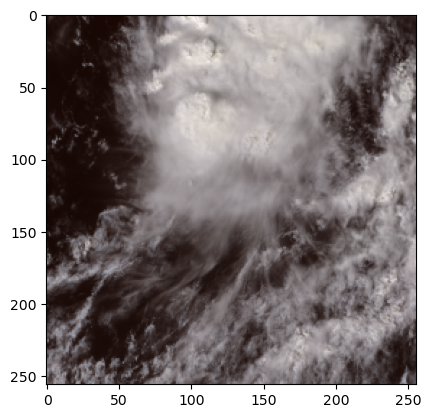

In [206]:
plt.imshow(dl.train_dataset[300][0].transpose(1,2,0))

In [207]:
test = model.model.unpatchify(
    model.model.forward(torch.tensor(dl.train_dataset[300][0][np.newaxis]), torch.tensor(dl.train_dataset[300][1][np.newaxis]), mask_ratio=0.75)[1]
).detach().numpy()[0]

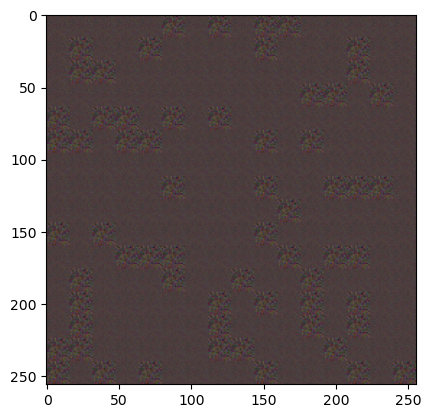

In [208]:
plt.imshow(test.transpose(1,2,0))